# Inspeção visual: HL0 × H0, hemorragia (FGADR _3, teste)

Os dois runs de hemorragia isolada em `outputs/_legado` (1 seed, pré-`--seed`):

- **H0** `exp_H0_hem_baseline`: UNet EfficientNet-B4 sem wavelet. É a **execução A (07-14)**, a
  mais fraca das duas execuções do H0.
- **HL0** `exp_HL0_hem_hilo_idwt_L1_allskips`: mesma UNet, com HiLo nas 4 skips.

Contexto (`docs/estado_da_pesquisa.md` §4): por fold, HL0 × H0_A dá +0.0174 (p=0.093) e
HL0 × H0_B dá +0.0076 (p=0.40). Os dois H0 são a mesma distribuição. **O ganho não se sustenta
com a escolha do baseline.** Este notebook é para *olhar onde* os modelos diferem, não para medir
o tamanho da diferença.

- Os runs legados não têm `run_config.json`. A config vem do registro (`experiments/`), com
  `allowed_suffixes=('3',)`, e o `load_state_dict` estrito garante que a arquitetura bate.
- Predição: média dos logits dos 5 folds, sigmoid, limiar 0.5, **sem TTA**. `FOLD = k` usa um fold só.
- O Dice por imagem daqui serve para escolher imagens. Não é evidência.

In [1]:
import os, sys, json, random
from pathlib import Path

import cv2                      # antes do torch (conflito de CXXABI)
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

REPO = Path('/home/lucas/mestrado/segmentation_retinopathy')
os.chdir(REPO)
sys.path.insert(0, str(REPO))
from experiments import EXPERIMENTS
from models import build_model

LEGADO = REPO / 'outputs/_legado'
ARMS = {                        # braço -> diretório com model_best_fold*.pth
    'H0': LEGADO / 'exp_H0_hem_baseline',
    'HL0': LEGADO / 'exp_HL0_hem_hilo_idwt_L1_allskips',
}
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
THR = 0.5      # limiar da avaliação do train.py
FOLD = None    # None = ensemble dos 5 folds; 0..4 = um fold só
LIMIT = None   # corta o conj. de teste nas tabelas (debug); None = todas

plt.rcParams['figure.dpi'] = 110
print('device:', DEVICE)

device: cuda


## Config e split de teste

In [2]:
# sem run_config.json nos legados: registro + o sufixo usado no treino (--suffixes 3)
configs = {a: EXPERIMENTS[a].derive(allowed_suffixes=('3',)) for a in ARMS}
config = configs['HL0']
CLS = config.classes[0]
H, W = config.image_size
for a, c in configs.items():
    print(f'{a:4s} {c.exp_name:28s} fusion={c.wavelet_fusion if c.has_wavelet else "-":5s} '
          f'skips={c.wavelet_skip_indices} encoder={c.encoder_name}')

# mesmo DataFrame e mesma ordem do train.py: presence csv + grau DR, filtro de sufixo, iloc do split
df = pd.read_csv(config.presence_csv)
dr = pd.read_csv(Path(config.fgadr_path) / 'DR_Seg_Grading_Label.csv',
                 header=None, names=['filename', 'dr_grade'])
df = df.merge(dr, on='filename', how='left')
suffix = df['filename'].str.rsplit('_', n=1).str[1].str.split('.').str[0]
df = df[suffix.isin(set(config.allowed_suffixes))].reset_index(drop=True)
splits = json.loads((REPO / 'outputs' / 'cv_splits_3.json').read_text())
test_df = df.iloc[splits['test']].reset_index(drop=True)

# confere com a ordem gravada pelos próprios runs
for a, d in ARMS.items():
    files = np.load(d / 'test_scores.npz', allow_pickle=True)['files']
    assert list(files) == list(test_df['filename']), f'split do {a} não confere'
print(f'{len(test_df)} imagens de teste (ordem confere com os test_scores.npz), '
      f'{int(test_df[CLS].sum())} com {CLS}')

H0   hem_baseline                 fusion=-     skips=() encoder=efficientnet-b4
HL0  hem_hilo_idwt_L1_allskips    fusion=hilo  skips=(0, 1, 2, 3) encoder=efficientnet-b4
89 imagens de teste (ordem confere com os test_scores.npz), 85 com Hemorrhage


## Modelos (5 folds por braço)

In [5]:
!nvidia-smi

Tue Sep 29 19:06:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.173.02             Driver Version: 580.173.02     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 4060 Ti     Off |   00000000:02:00.0 Off |                  N/A |
|  0%   35C    P2             27W /  165W |    1762MiB /  16380MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
models = {}
for a, d in ARMS.items():
    models[a] = []
    for p in sorted(d.glob('model_best_fold*.pth')):
        m = build_model(configs[a])
        m.load_state_dict(torch.load(p, map_location='cpu', weights_only=False)['model_state_dict'])
        models[a].append(m.eval().to(DEVICE))
    print(f'{a}: {len(models[a])} folds')

H0: 5 folds
HL0: 5 folds


## Carregamento, predição e plots

In [6]:
MASK_DIR = {'HardExudate': 'HardExudate_Masks', 'Hemorrhage': 'Hemohedge_Masks',
            'SoftExudate': 'SoftExudate_Masks', 'Microaneurysms': 'Microaneurysms_Masks'}[CLS]
MEAN = np.array([0.485, 0.456, 0.406], np.float32)
STD = np.array([0.229, 0.224, 0.225], np.float32)
FGADR = Path(config.fgadr_path)
FULL = (slice(None), slice(None))


def load_sample(fname):
    # replica a transform de teste do dataset.py: Resize(H, W) + Normalize(ImageNet)
    img = cv2.cvtColor(cv2.imread(str(FGADR / 'Original_Images' / fname)), cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (W, H), interpolation=cv2.INTER_LINEAR)
    gt = np.zeros((H, W), bool)
    p = FGADR / MASK_DIR / fname
    if p.exists():
        m = (cv2.imread(str(p), cv2.IMREAD_GRAYSCALE) > config.bin_threshold).astype(np.uint8)
        gt = cv2.resize(m, (W, H), interpolation=cv2.INTER_NEAREST).astype(bool)
    x = torch.from_numpy(((img.astype(np.float32) / 255 - MEAN) / STD).transpose(2, 0, 1))
    return img, gt, x


@torch.no_grad()
def predict(x, arm, fold=FOLD):
    # média dos logits entre folds, depois sigmoid (igual ao ensemble do train.py)
    ms = models[arm] if fold is None else [models[arm][fold]]
    xb = x[None].to(DEVICE)
    logits = sum(m(xb) for m in ms) / len(ms)
    return torch.sigmoid(logits)[0, 0].float().cpu().numpy()     # [H, W]


def run(fname, fold=FOLD):
    img, gt, x = load_sample(fname)
    return img, gt, {a: predict(x, a, fold) for a in ARMS}


def dice(pred, gt):
    s = pred.sum() + gt.sum()
    return np.nan if s == 0 else 2 * (pred & gt).sum() / s


def fmt(d):
    return '–' if np.isnan(d) else f'{d:.3f}'


def _dim(img):
    g = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY).astype(np.float32) * 0.35
    return np.repeat(g[..., None], 3, axis=2)


def gt_overlay(img, gt, alpha=0.55):
    out = img.astype(np.float32).copy()
    out[gt] = (1 - alpha) * out[gt] + alpha * np.array((230, 30, 60), np.float32)
    return out.clip(0, 255).astype(np.uint8)


def error_map(img, pred, gt):
    # TP verde, FP vermelho, FN azul sobre a imagem em cinza escurecida
    out = _dim(img)
    out[pred & gt] = (0, 230, 0)
    out[pred & ~gt] = (255, 40, 40)
    out[~pred & gt] = (40, 120, 255)
    return out.clip(0, 255).astype(np.uint8)


def diff_map(img, a, b):
    # onde as predições dos dois braços discordam: amarelo só a, magenta só b, cinza os dois
    out = _dim(img)
    out[a & b] = (170, 170, 170)
    out[a & ~b] = (255, 220, 0)
    out[~a & b] = (255, 0, 255)
    return out.clip(0, 255).astype(np.uint8)


def draw(fname, img, gt, prob, sl=FULL, thr=THR):
    pred = {a: prob[a] > thr for a in ARMS}
    d = {a: dice(pred[a], gt) for a in ARMS}
    where = '' if sl is FULL else f' [{sl[0].start}:{sl[0].stop}, {sl[1].start}:{sl[1].stop}]'
    fig, ax = plt.subplots(2, 3, figsize=(15, 10))
    ax[0, 0].imshow(img[sl]); ax[0, 0].set_title(fname + where)
    ax[0, 1].imshow(gt_overlay(img, gt)[sl]); ax[0, 1].set_title(f'GT {CLS} ({gt.sum()} px)')
    ax[0, 2].imshow(diff_map(img, pred['HL0'], pred['H0'])[sl])
    ax[0, 2].set_title('amarelo: só HL0 | magenta: só H0\ncinza: os dois')
    for j, a in enumerate(ARMS):
        ax[1, j].imshow(error_map(img, pred[a], gt)[sl])
        ax[1, j].set_title(f'{a}: Dice {fmt(d[a])}, {pred[a].sum()} px pred\n'
                           f'TP verde / FP verm. / FN azul')
    im = ax[1, 2].imshow((prob['HL0'] - prob['H0'])[sl], cmap='coolwarm', vmin=-1, vmax=1)
    ax[1, 2].set_title('prob HL0 − prob H0')
    plt.colorbar(im, ax=ax[1, 2], fraction=0.046)
    for a in ax.flat: a.axis('off')
    plt.tight_layout(); plt.show()


def show(fname, thr=THR, fold=FOLD):
    out = run(fname, fold)
    draw(fname, *out, thr=thr)
    return out


def show_zoom(fname, size=128, on='diff', thr=THR, fold=FOLD, out=None):
    # recorte na região mais densa de: 'diff' = discordância entre os braços,
    # 'gt' = hemorragia anotada, 'err' = erros (FP+FN) dos dois somados
    img, gt, prob = out if out is not None else run(fname, fold)
    pred = {a: prob[a] > thr for a in ARMS}
    target = {'diff': pred['HL0'] ^ pred['H0'],
              'gt': gt,
              'err': (pred['HL0'] ^ gt) | (pred['H0'] ^ gt)}[on]
    dens = cv2.blur(target.astype(np.float32), (size, size))
    if dens.max() == 0:
        print(f'{fname}: nada para "{on}"'); return
    cy, cx = np.unravel_index(dens.argmax(), dens.shape)
    y0 = int(np.clip(cy - size // 2, 0, H - size)); x0 = int(np.clip(cx - size // 2, 0, W - size))
    draw(fname, img, gt, prob, (slice(y0, y0 + size), slice(x0, x0 + size)), thr)

## Amostra aleatória do teste (re-execute para ver outras)

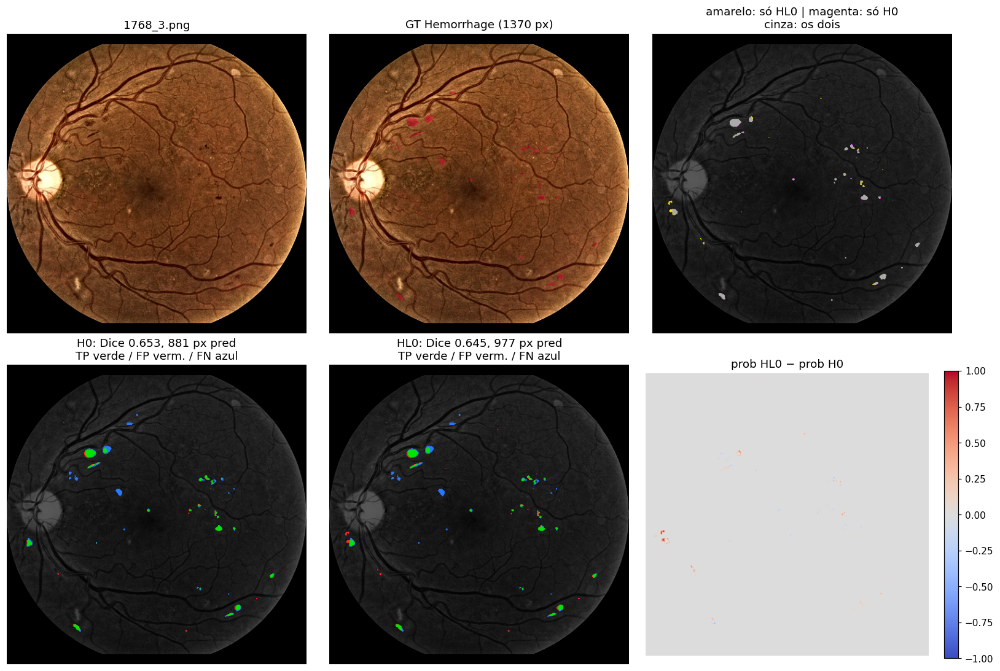

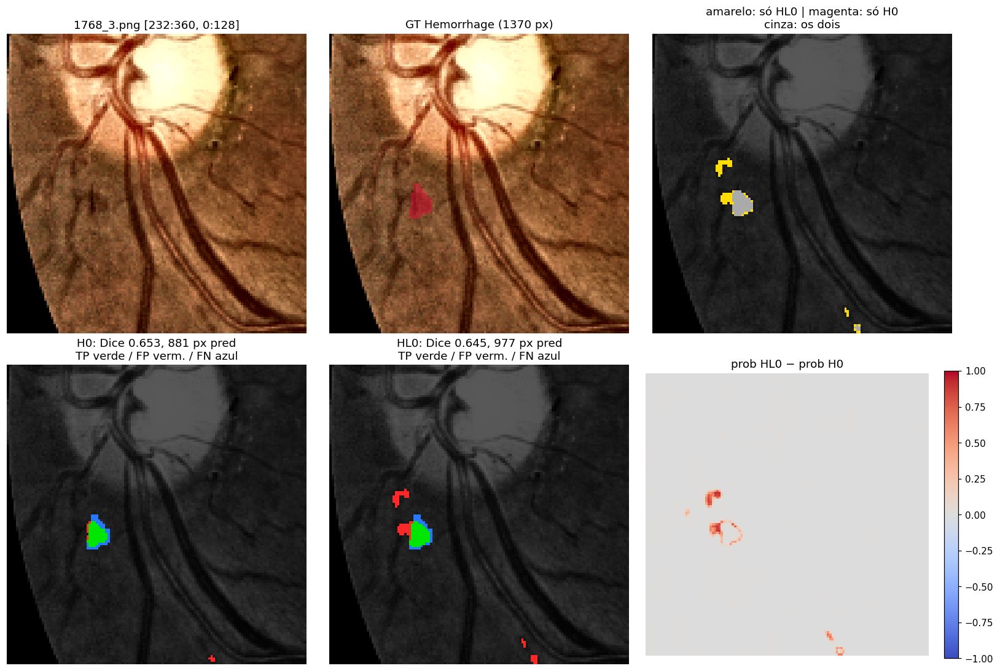

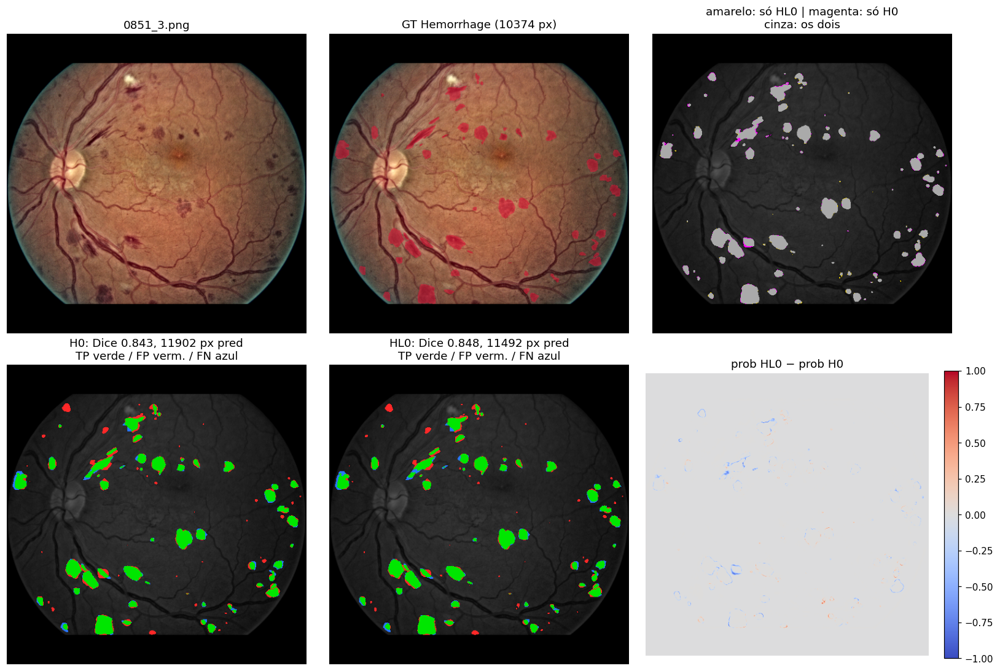

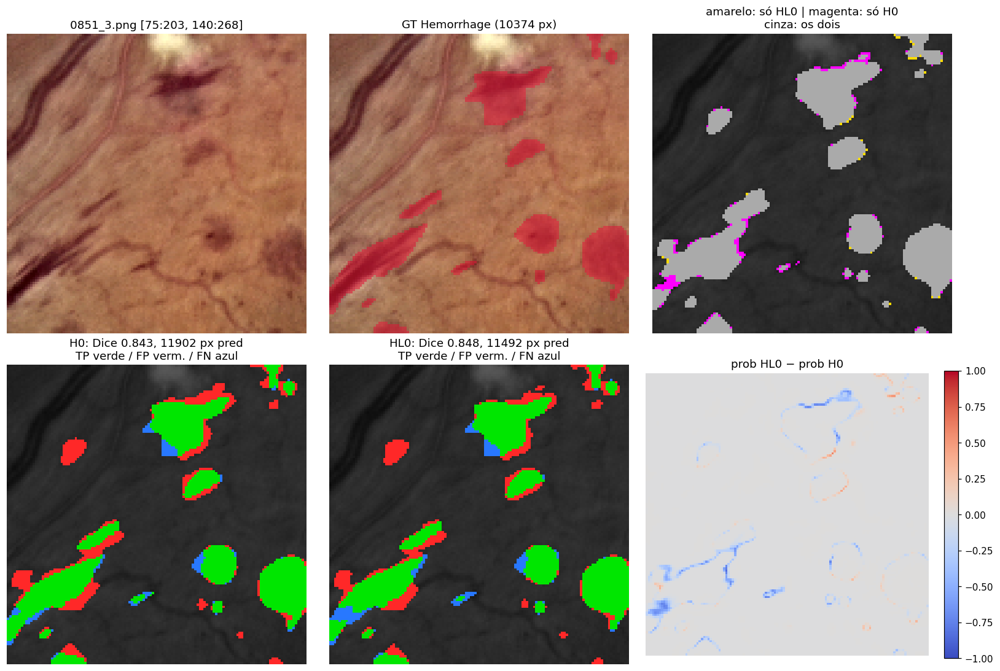

In [7]:
N = 2
for fname in random.sample(list(test_df['filename']), N):
    out = show(fname)
    show_zoom(fname, size=128, on='diff', out=out)

## Uma imagem específica

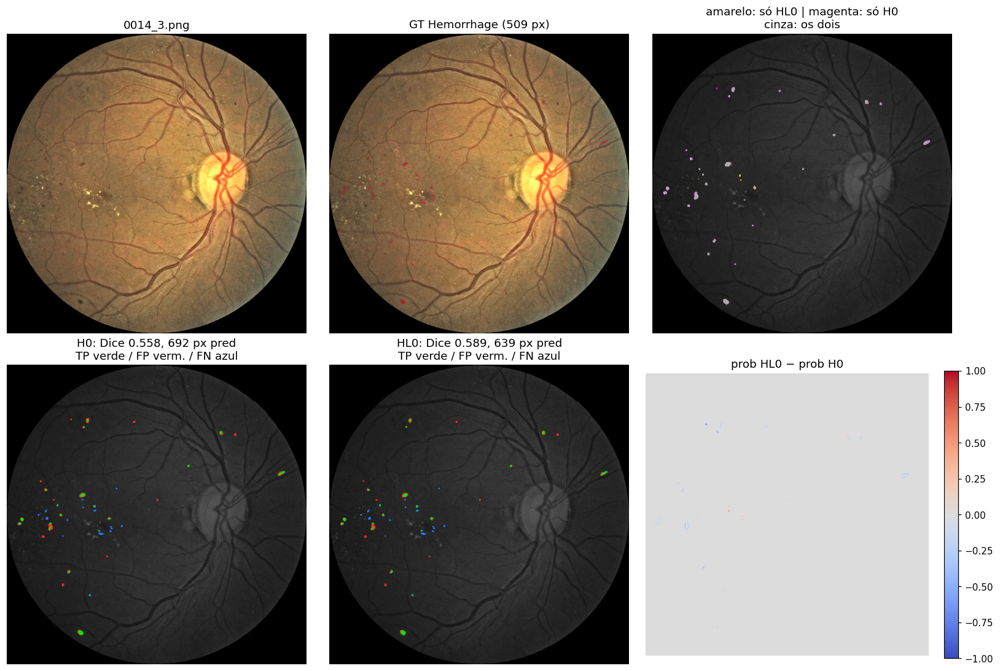

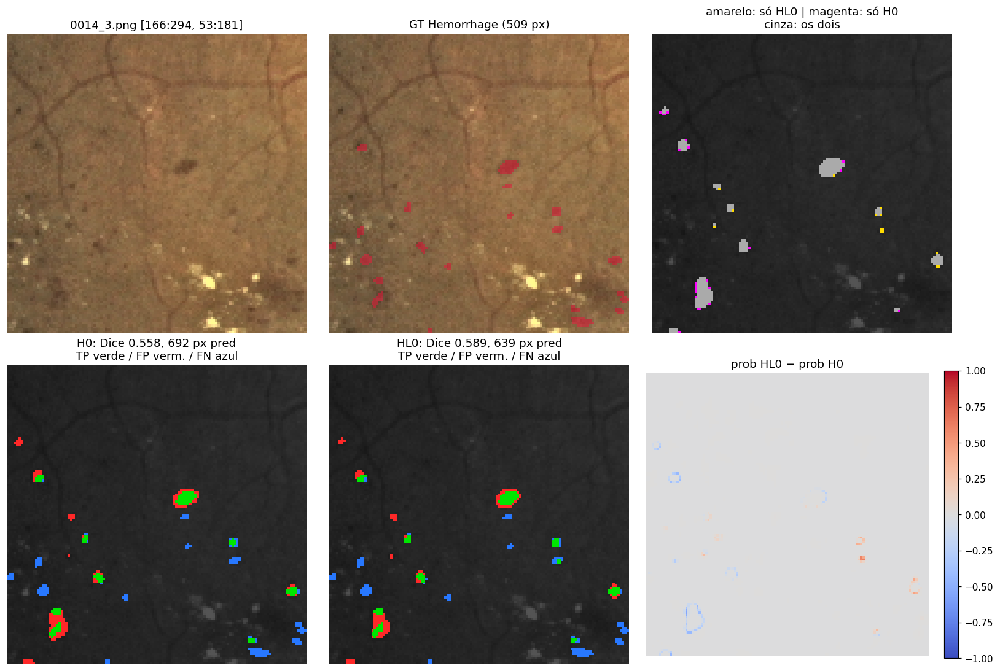

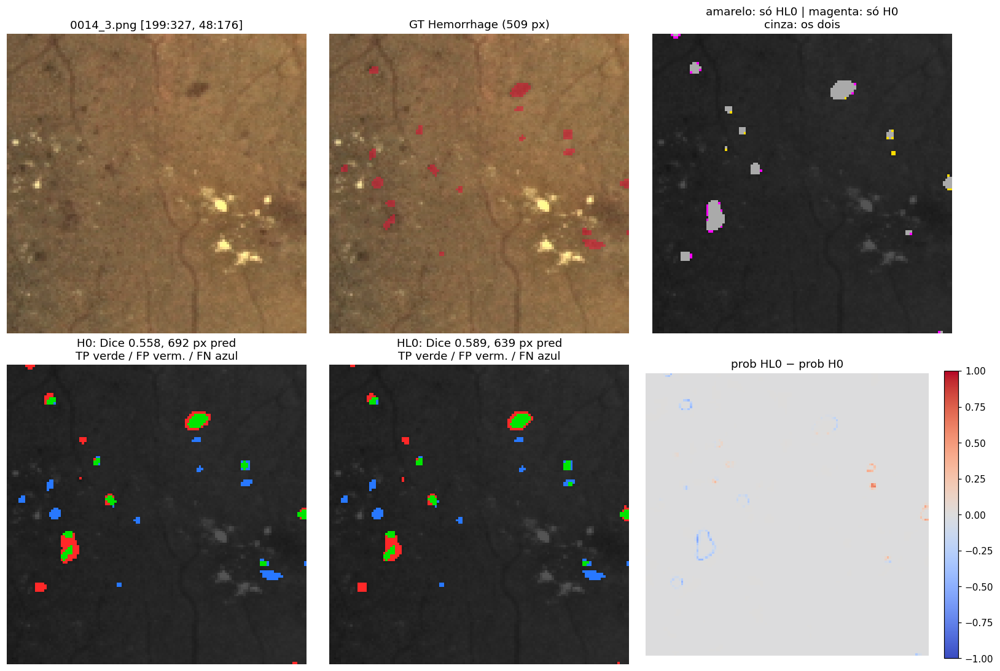

In [8]:
fname = test_df['filename'].iloc[0]      # troque pelo nome que quiser, ex. '0563_3.png'
out = show(fname)
show_zoom(fname, size=128, on='gt', out=out)
show_zoom(fname, size=128, on='diff', out=out)

## Dice por imagem nos dois braços

Roda as 89 imagens × 10 modelos. `delta = HL0 − H0`. A tabela é descritiva: ela aponta onde
olhar, não diz se a diferença é real (ver o cabeçalho).

85 imagens com Hemorrhage: Dice médio por imagem H0 0.6408 | HL0 0.6535
HL0 melhor por >0.02 em 25, pior por >0.02 em 4, empate em 56
pixels FP somados: H0 51190 | HL0 50298; FN somados: H0 54484 | HL0 52671


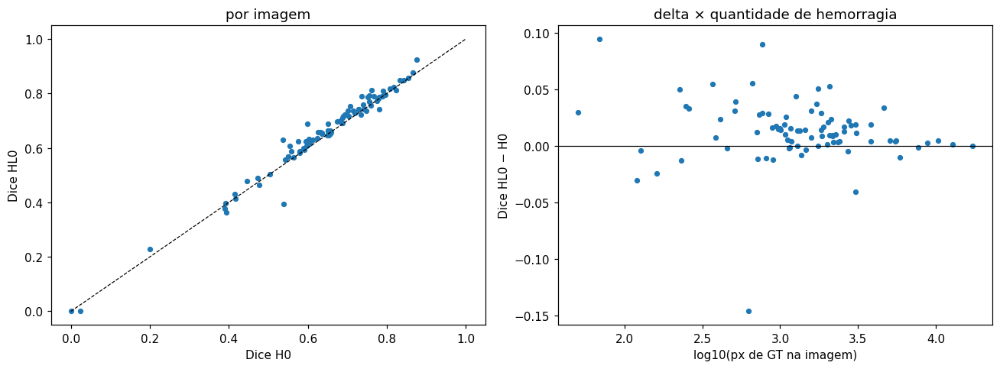

,filename,gt_px,dice_H0,pred_px_H0,fp_px_H0,fn_px_H0,dice_HL0,pred_px_HL0,fp_px_HL0,fn_px_HL0,delta
85,1795_3.png,627,0.538462,1297,779,109,0.392537,2053,1527,101,-0.145924
26,0503_3.png,3046,0.781108,3560,980,466,0.740546,3036,784,794,-0.040562
59,1195_3.png,120,0.392857,48,15,87,0.362416,29,2,93,-0.030441
80,1716_3.png,161,0.024096,5,3,159,0.000000,6,6,161,-0.024096
48,0874_3.png,232,0.476190,293,168,107,0.463158,243,133,122,-0.013033


In [9]:
rows = []
for fname in list(test_df['filename'])[:LIMIT]:
    img, gt, prob = run(fname)
    r = {'filename': fname, 'gt_px': int(gt.sum())}
    for a in ARMS:
        pred = prob[a] > THR
        r[f'dice_{a}'] = dice(pred, gt)
        r[f'pred_px_{a}'] = int(pred.sum())
        r[f'fp_px_{a}'] = int((pred & ~gt).sum())
        r[f'fn_px_{a}'] = int((~pred & gt).sum())
    rows.append(r)
per_img = pd.DataFrame(rows)
per_img['delta'] = per_img['dice_HL0'] - per_img['dice_H0']

has = per_img[per_img['gt_px'] > 0]
print(f'{len(has)} imagens com {CLS}: Dice médio por imagem '
      f'H0 {has["dice_H0"].mean():.4f} | HL0 {has["dice_HL0"].mean():.4f}')
print(f'HL0 melhor por >0.02 em {(has["delta"] > 0.02).sum()}, pior por >0.02 em '
      f'{(has["delta"] < -0.02).sum()}, empate em {(has["delta"].abs() <= 0.02).sum()}')
print(f'pixels FP somados: H0 {per_img["fp_px_H0"].sum()} | HL0 {per_img["fp_px_HL0"].sum()}; '
      f'FN somados: H0 {per_img["fn_px_H0"].sum()} | HL0 {per_img["fn_px_HL0"].sum()}')

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].scatter(has['dice_H0'], has['dice_HL0'], s=14)
ax[0].plot([0, 1], [0, 1], 'k--', lw=0.8)
ax[0].set_xlabel('Dice H0'); ax[0].set_ylabel('Dice HL0'); ax[0].set_title('por imagem')
ax[1].scatter(np.log10(has['gt_px']), has['delta'], s=14)
ax[1].axhline(0, color='k', lw=0.8)
ax[1].set_xlabel('log10(px de GT na imagem)'); ax[1].set_ylabel('Dice HL0 − H0')
ax[1].set_title('delta × quantidade de hemorragia')
plt.tight_layout(); plt.show()
per_img.sort_values('delta').head()

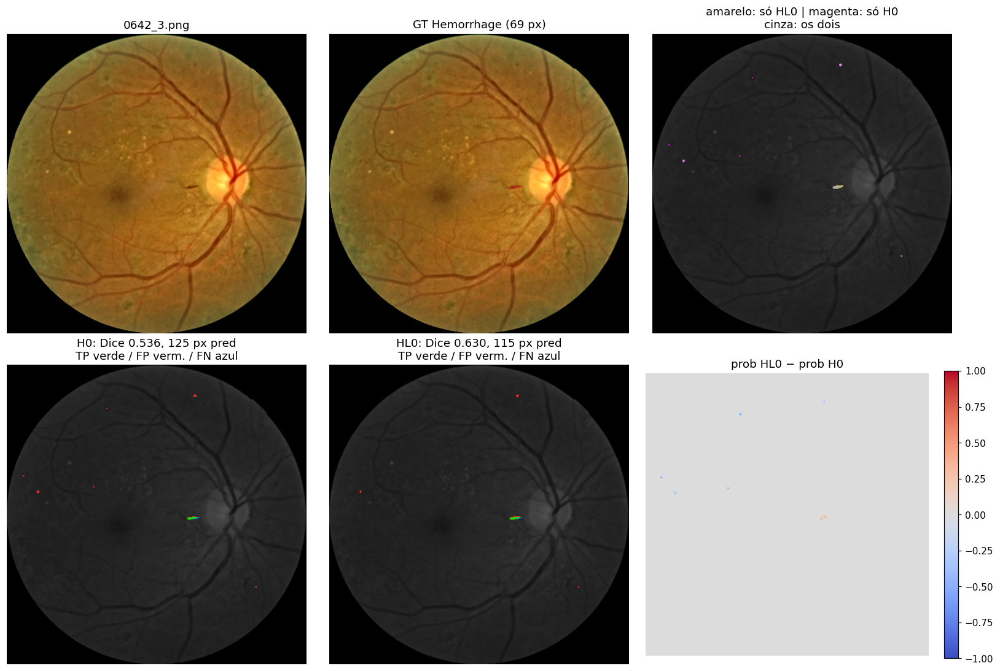

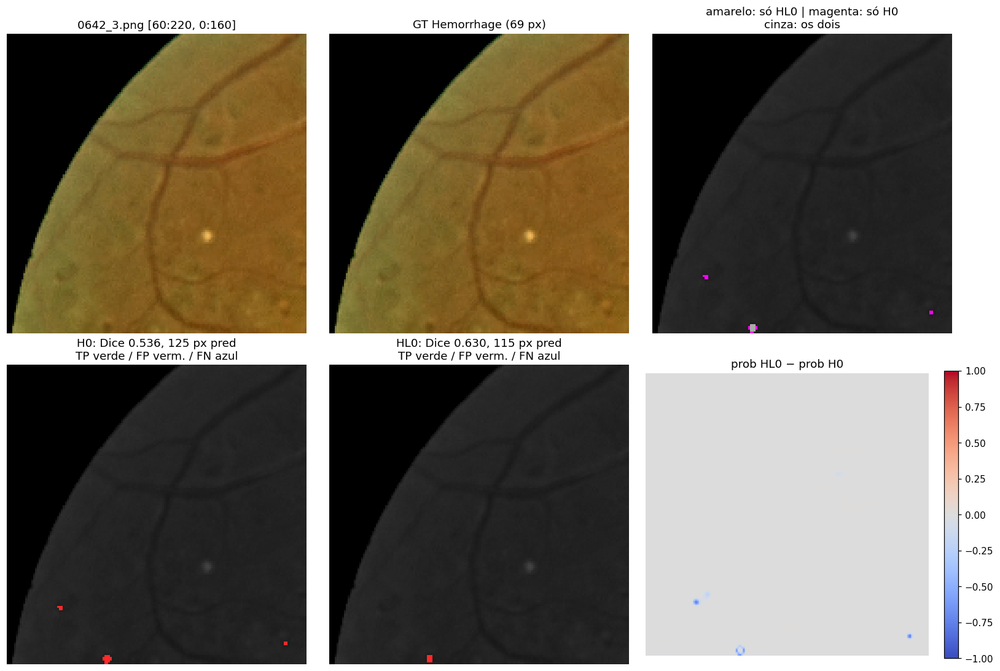

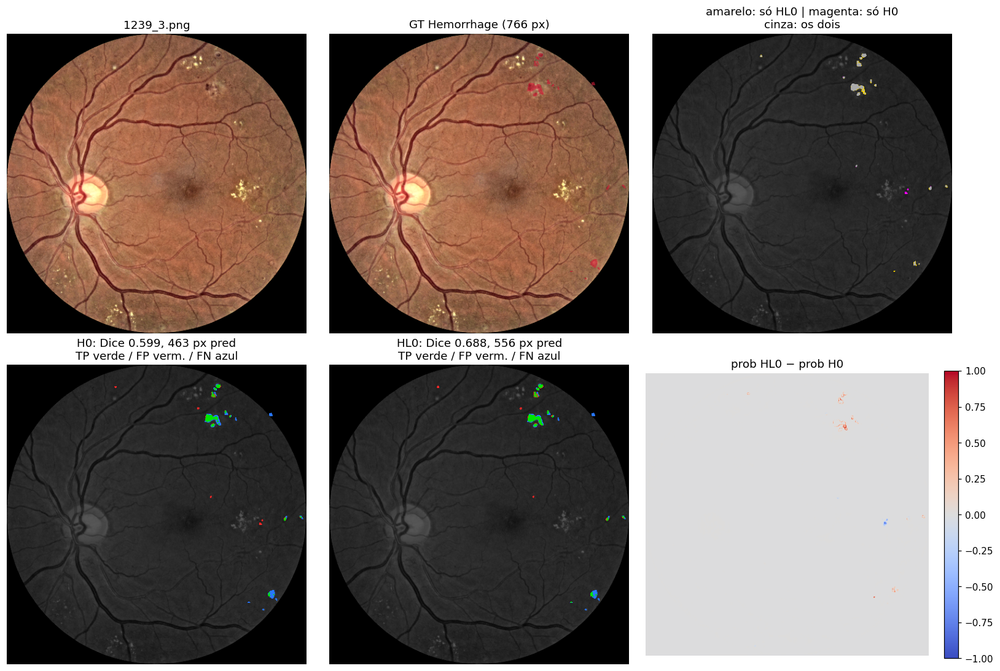

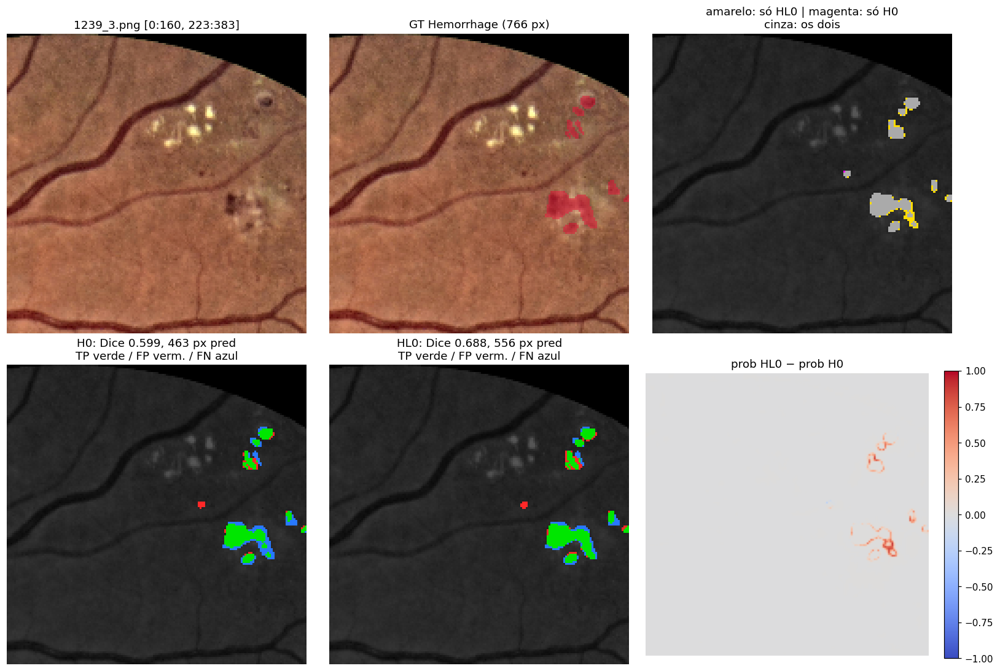

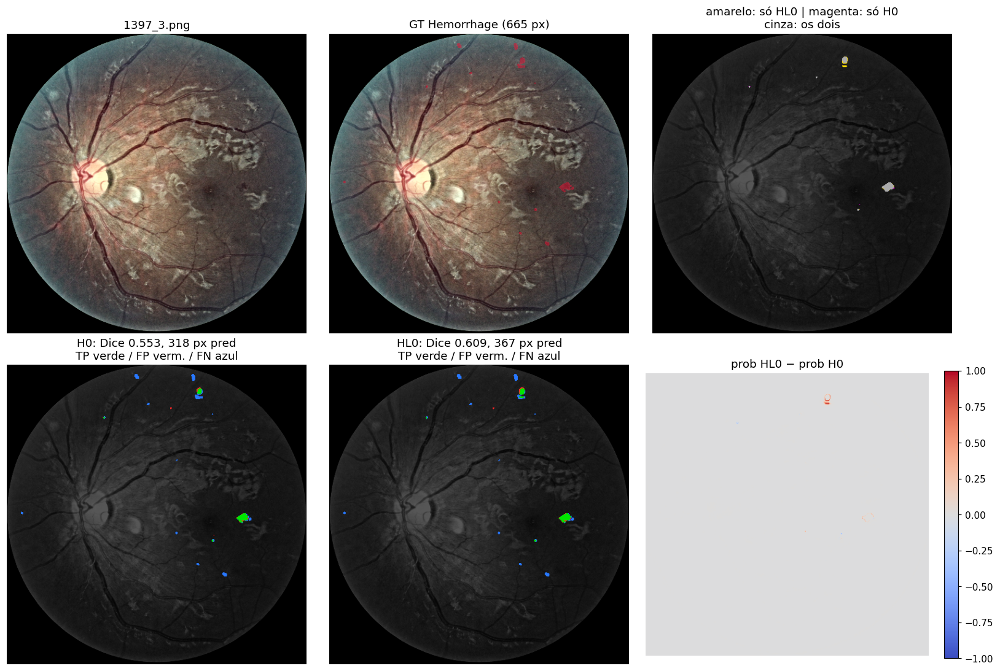

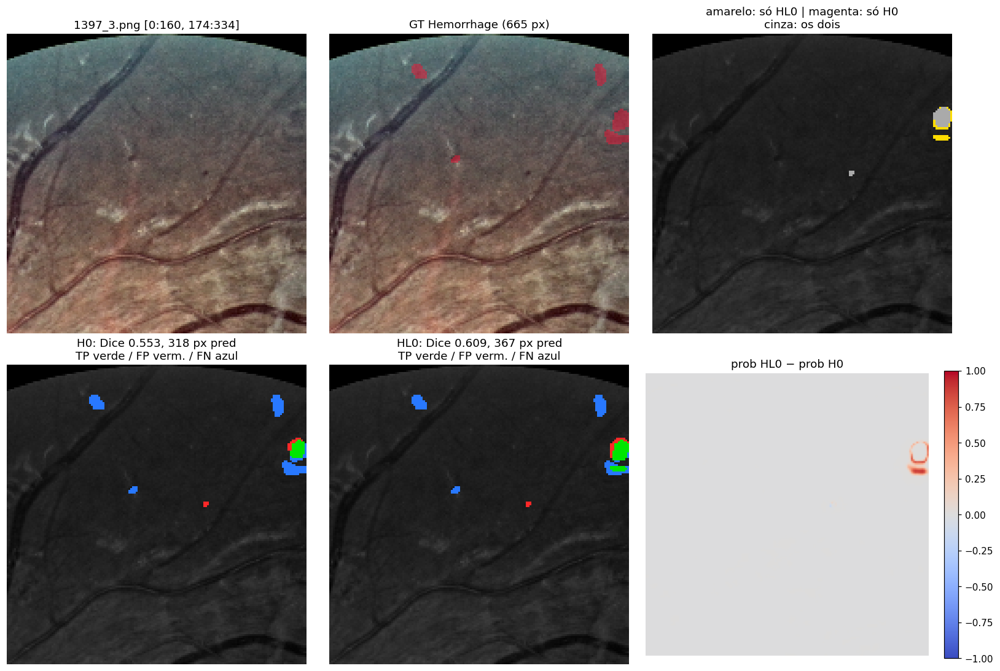

In [10]:
# onde o HL0 mais ganha do H0
n = 3
for fname in has.sort_values('delta', ascending=False)['filename'].head(n):
    out = show(fname)
    show_zoom(fname, size=160, on='diff', out=out)

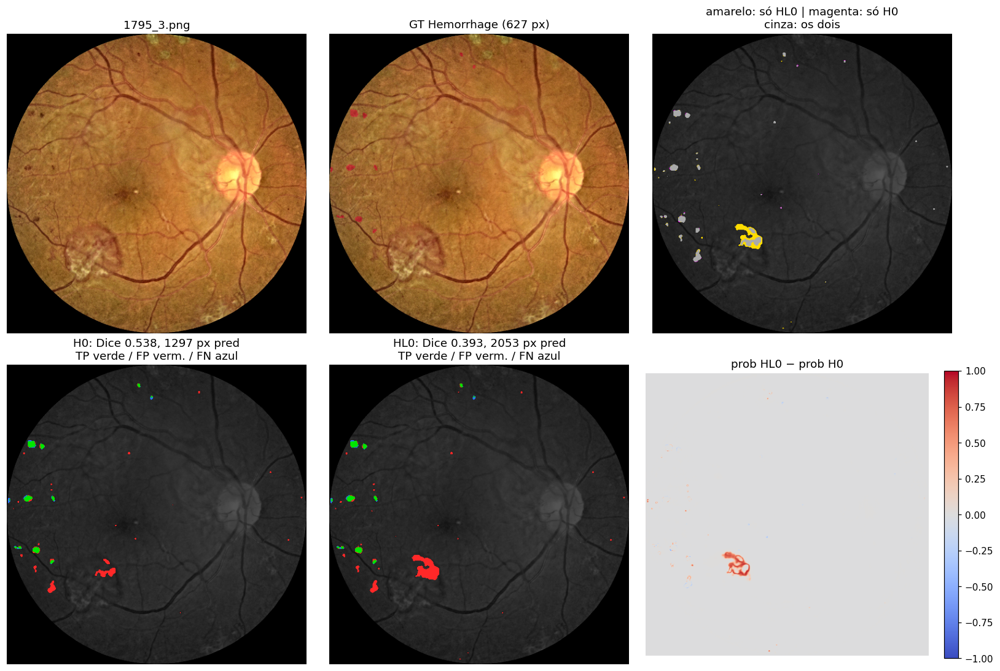

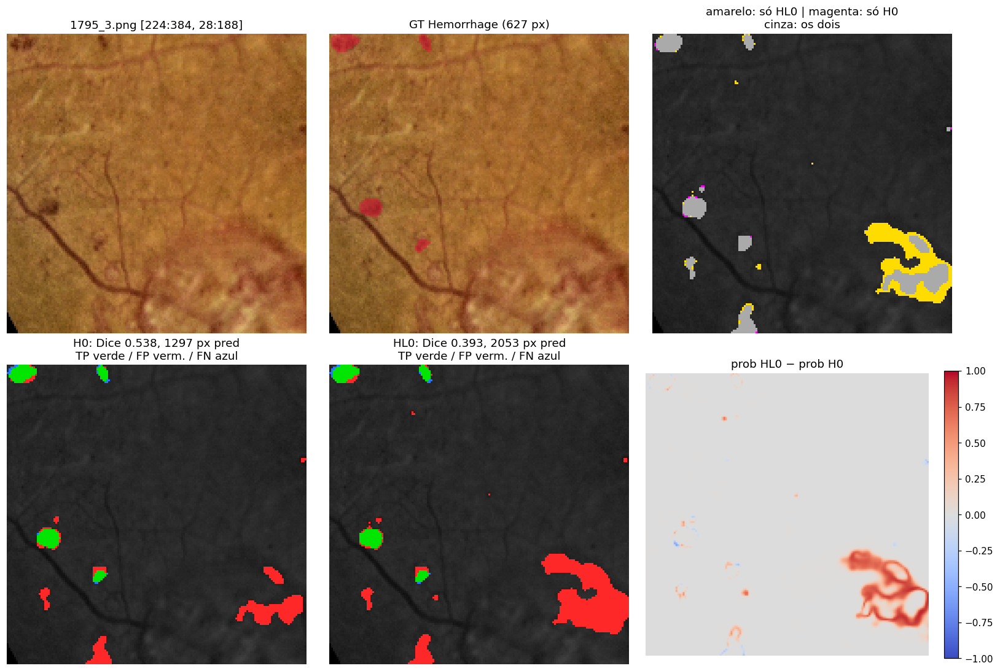

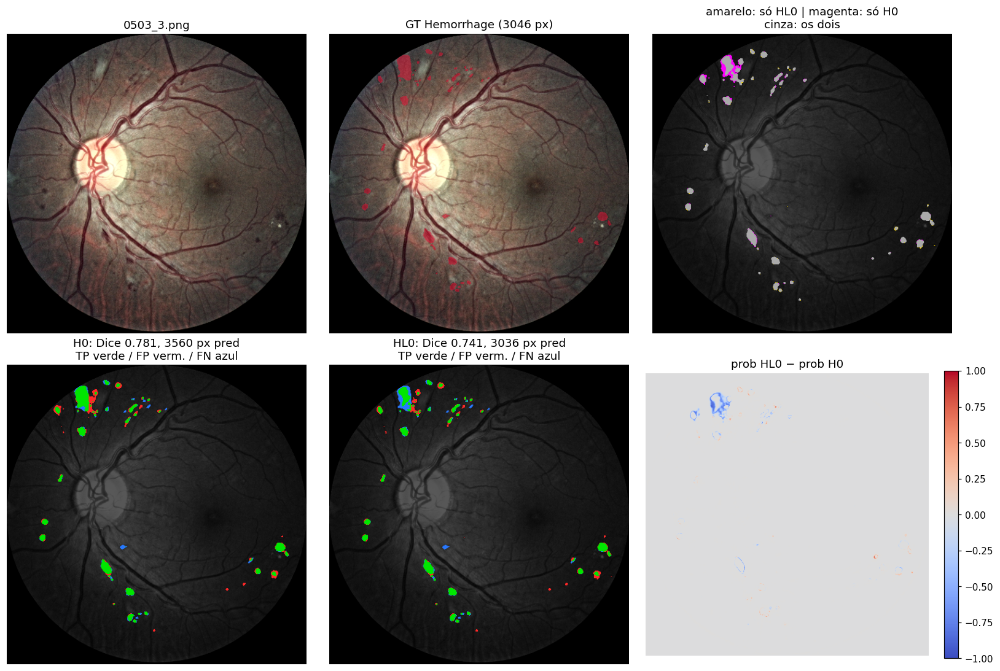

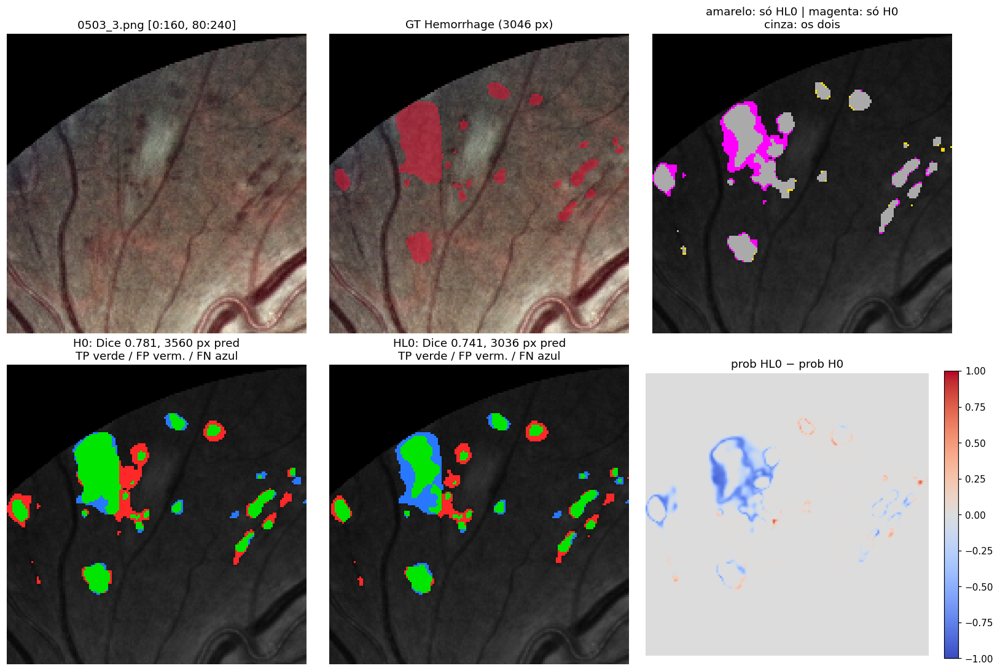

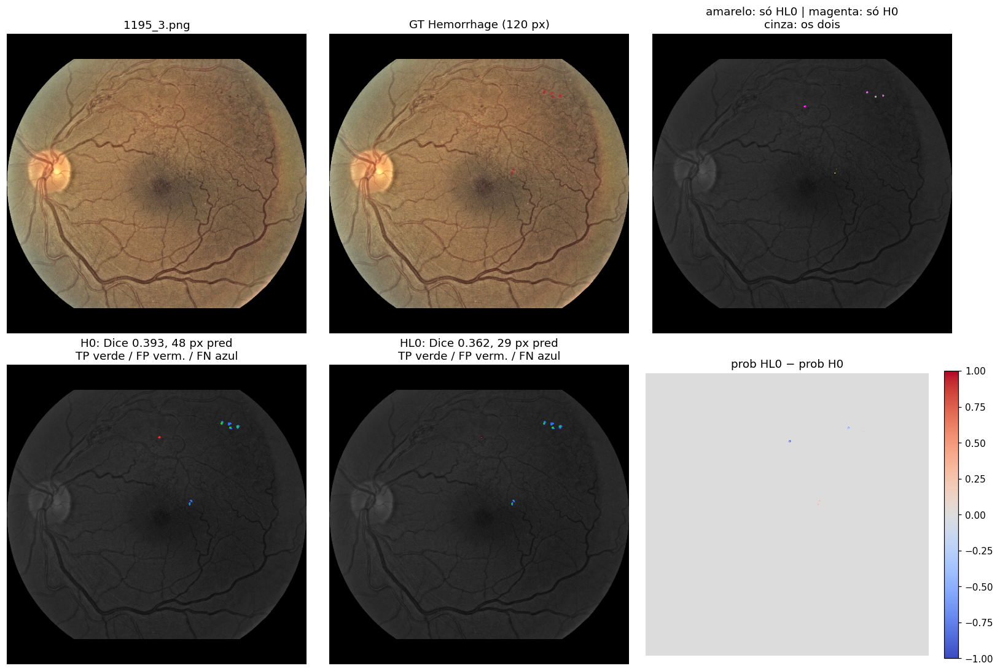

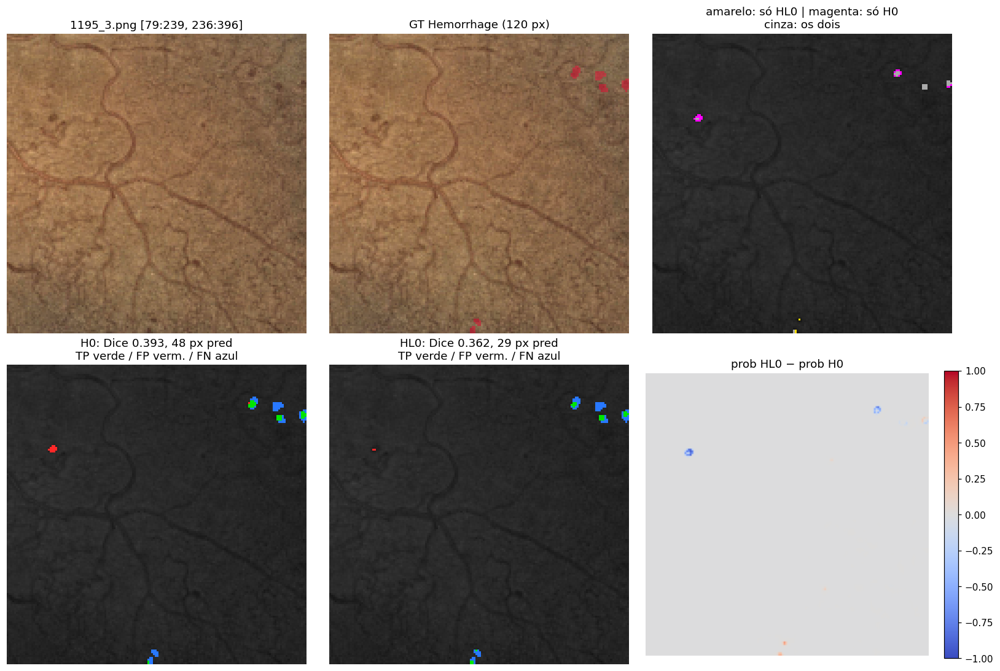

In [11]:
# onde o HL0 mais perde para o H0
n = 3
for fname in has.sort_values('delta')['filename'].head(n):
    out = show(fname)
    show_zoom(fname, size=160, on='diff', out=out)

## O HiLo está fazendo alguma coisa?

1. Escala efetiva por skip: `|α| · ||proj_out.weight||` (Frobenius), por fold do HL0.
2. Resíduo que o HiLo soma na skip, `|out − x|` médio nos canais, capturado com hook. O contorno
   vermelho é a GT de hemorragia. `dentro/fora` é o resíduo médio nos pixels de hemorragia dividido
   pelo resíduo médio no resto do campo retiniano, na resolução daquela skip.
3. Esse `dentro/fora` agregado no teste inteiro diz se o HiLo mexe **mais onde tem hemorragia** do
   que no fundo. Cuidado ao ler: (a) a hemorragia é região escura de alto contraste, e qualquer
   módulo que responda a contraste daria >1 sem "saber" o que é lesão; (b) o "fora" inclui vasos e
   a borda do campo, onde o resíduo do skip0 é forte; (c) nas skips grossas (32 px) a GT reamostrada
   fica dilatada. Não há controle equivalente no H0, que não tem o módulo.

In [12]:
scale = pd.DataFrame({
    f'fold{i}': {f'skip{k}': (m.wavelet_modules[k].alpha.abs() *
                               m.wavelet_modules[k].proj_out.weight.norm()).item()
                 for k in m.wavelet_modules}
    for i, m in enumerate(models['HL0'])})
scale['alpha_fold0'] = [models['HL0'][0].wavelet_modules[k[4:]].alpha.item() for k in scale.index]
scale.round(4)

,fold0,fold1,fold2,fold3,fold4,alpha_fold0
skip0,1.5272,1.7090,1.2695,1.5388,1.4302,0.2745
skip1,1.3354,1.6730,1.3773,1.4380,1.4341,0.2766
skip2,1.0920,1.3848,1.2596,1.3126,1.1979,0.2136
skip3,1.3280,1.3698,1.4915,1.7725,1.2587,0.1704


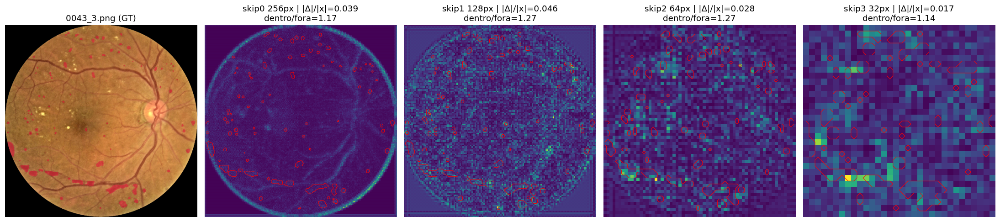

In [13]:
@torch.no_grad()
def hilo_maps(fname, fold=0):
    # hook em cada HiLoWaveletSkip do HL0: |out - x| e |x| médios nos canais,
    # mais as máscaras de GT e de campo retiniano na resolução de cada skip
    m = models['HL0'][fold]
    store, hooks = {}, []
    for k, mod in m.wavelet_modules.items():
        def hook(mod, inp, out, k=k):
            x = inp[0]
            store[k] = ((out - x).abs().mean(1)[0].float().cpu().numpy(),
                        x.abs().mean(1)[0].float().cpu().numpy())
        hooks.append(mod.register_forward_hook(hook))
    img, gt, x = load_sample(fname)
    try:
        m(x[None].to(DEVICE))
    finally:
        for h in hooks: h.remove()
    fov = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY) > 10
    res = {}
    for k, (d, xm) in store.items():
        h, w = d.shape
        g = cv2.resize(gt.astype(np.float32), (w, h), interpolation=cv2.INTER_AREA) > 0
        f = cv2.resize(fov.astype(np.float32), (w, h), interpolation=cv2.INTER_AREA) > 0.5
        bg = f & ~g
        ratio = d[g].mean() / d[bg].mean() if g.any() and bg.any() else np.nan
        res[k] = dict(delta=d, rel=d.mean() / (xm.mean() + 1e-8), gt=g, ratio=ratio)
    return img, gt, res


def plot_hilo(fname, fold=0):
    img, gt, res = hilo_maps(fname, fold)
    fig, ax = plt.subplots(1, len(res) + 1, figsize=(4 * (len(res) + 1), 4.5))
    ax[0].imshow(gt_overlay(img, gt)); ax[0].set_title(f'{fname} (GT)')
    for a, (k, r) in zip(ax[1:], res.items()):
        a.imshow(r['delta'], cmap='viridis')
        if r['gt'].any():
            a.contour(r['gt'], levels=[0.5], colors='red', linewidths=0.6)
        a.set_title(f'skip{k} {r["delta"].shape[0]}px | |Δ|/|x|={r["rel"]:.3f}\n'
                    f'dentro/fora={r["ratio"]:.2f}')
    for a in ax: a.axis('off')
    plt.tight_layout(); plt.show()


# uma imagem com bastante hemorragia, sorteada no quartil de cima (usa `has`, da tabela de Dice)
plot_hilo(random.choice(list(has.sort_values('gt_px')['filename'].tail(max(1, len(has) // 4)))))

In [14]:
# dentro/fora agregado no teste (fold 0): >1 = o HiLo altera mais a skip onde há hemorragia
rows = []
for fname in list(test_df['filename'])[:LIMIT]:
    _, gt, res = hilo_maps(fname, fold=0)
    if gt.any():
        rows.append({f'skip{k}': r['ratio'] for k, r in res.items()})
ratios = pd.DataFrame(rows)
print(f'{len(ratios)} imagens com {CLS}')
ratios.describe().loc[['mean', '25%', '50%', '75%']].round(3)

85 imagens com Hemorrhage


,skip0,skip1,skip2,skip3
mean,1.202,1.268,1.188,1.196
25%,1.105,1.194,1.116,1.113
50%,1.177,1.256,1.194,1.175
75%,1.274,1.316,1.276,1.274
